## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback

- Dataset #4
  - Dataset Name: **Social Media and Mental Health** (survey; `smmh.csv`)
  - Link to the dataset (official Kaggle page): `https://www.kaggle.com/datasets/souvikahmed071/social-media-and-mental-health`
  - Reproducible raw CSV mirror used in this repo (no Kaggle login required): `https://raw.githubusercontent.com/Daerkns/correlation-between-social-media-and-mental-health/main/smmh.csv`
  - Number of observations: **481** survey responses (rows)
  - Number of variables: **21** columns
  - Description of the variables most relevant to this project:
    - Demographics/controls: age, gender, relationship status, occupation status, affiliated organization type
    - Social media usage: whether they use social media, which platforms (comma-separated list), and average time spent per day (categorical bins)
    - Wellbeing / mental health proxies (mostly Likert 1–5): distractedness, worries, concentration difficulty, social comparison frequency + feelings about comparisons, validation seeking, feeling depressed/down, interest fluctuation, sleep issues
  - Shortcomings / limitations:
    - Cross-sectional and self-reported survey data (no causal conclusions; subject to recall/social desirability bias)
    - Does not include direct “active interaction” counts (posting/commenting/DMs); we will treat it as a **supporting** dataset and use available proxies (time-spent, platforms, comparison/validation items)
    - Potential sample bias (survey respondents are not representative of all adults)
    - Small number of potentially inconsistent responses (e.g., `Do you use social media? = No` but other usage questions answered) that we will flag and handle explicitly in cleaning


In [6]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# Setup code -- Run only once after cloning!!! 
#
# This cell downloads the data from its source to the `data/00-raw/` directory.
# If the data hasn't updated you don't need to do this again.

import os
import subprocess
from pathlib import Path

# Ensure the destination directory exists (fresh clones may not have it yet)
RAW_DIR = Path('data/00-raw')
RAW_DIR.mkdir(parents=True, exist_ok=True)

# For this checkpoint, we include **Dataset #4** only.
datafiles = [
    {
        'url': 'https://raw.githubusercontent.com/Daerkns/correlation-between-social-media-and-mental-health/main/smmh.csv',
        'filename': 'smmh.csv'
    },

    # Template examples (kept for reference; not used)
    # { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    # { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

def download_if_missing(url: str, dest: Path) -> None:
    if dest.exists() and dest.stat().st_size > 0:
        print(f"Already exists: {dest}")
        return

    print(f"Downloading: {url}")
    # Use curl for robust HTTPS without extra Python packages
    subprocess.run([
        'curl', '-L', '--fail', url,
        '-o', str(dest)
    ], check=True)
    print(f"Saved: {dest} ({dest.stat().st_size} bytes)")

for f in datafiles:
    download_if_missing(f['url'], RAW_DIR / f['filename'])

Already exists: data/00-raw/smmh.csv


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [8]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [9]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

### Dataset #4: Social Media and Mental Health (`smmh.csv`)

This dataset is a cross-sectional survey about social media use and mental-health / wellbeing proxy measures. It is well-suited for exploratory analysis of how **time spent on social media** (a proxy for exposure / consumption intensity) and behaviors like **social comparison** and **validation seeking** relate to outcomes like **sleep issues** and **feeling depressed/down**.

Below, we download the raw data into `data/00-raw/`, wrangle it into a reproducible cleaned table in `data/02-processed/`, and then reload that processed file for EDA.

In [10]:
from pathlib import Path
import os
import subprocess
import sys
import importlib.util

# Ensure required packages exist in *this* notebook kernel
required = ["pandas", "numpy", "matplotlib", "seaborn"]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)

import pandas as pd
import numpy as np

RAW_DIR = Path("data/00-raw")
INTERIM_DIR = Path("data/01-interim")
PROCESSED_DIR = Path("data/02-processed")

RAW_DIR.mkdir(parents=True, exist_ok=True)
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SMMH_URL = "https://raw.githubusercontent.com/Daerkns/correlation-between-social-media-and-mental-health/main/smmh.csv"
SMMH_RAW_PATH = RAW_DIR / "smmh.csv"

def download_to_path(url: str, path: Path) -> None:
    subprocess.run(["curl", "-L", "--fail", url, "-o", str(path)], check=True)

# Download only if missing/empty (reproducible, no Kaggle login required)
if (not SMMH_RAW_PATH.exists()) or (SMMH_RAW_PATH.stat().st_size == 0):
    print(f"Downloading: {SMMH_URL}")
    download_to_path(SMMH_URL, SMMH_RAW_PATH)
    print(f"Saved to: {SMMH_RAW_PATH} ({SMMH_RAW_PATH.stat().st_size} bytes)")
else:
    print(f"Already exists: {SMMH_RAW_PATH} ({SMMH_RAW_PATH.stat().st_size} bytes)")

df_raw = pd.read_csv(SMMH_RAW_PATH, skipinitialspace=True)
print("Raw shape:", df_raw.shape)
print("Raw columns (first 10):", df_raw.columns.tolist()[:10])
df_raw.head(3)

Installing missing packages: ['pandas', 'seaborn']
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 9.2 MB/s eta 0:00:00a 0:00:01m
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Already exists: data/00-raw/smmh.csv (77195 bytes)
Raw shape: (481, 21)
Raw columns (first 10): ['Timestamp', '1. What is your age?', '2. Gender', '3. Relationship Status', '4. Occupation Status', '5. What type of organizations are you affiliated with?', '6. Do you use social media?', '7. What social media platforms do you commonly use?', '8. What is the average time you spend on social media every day?', '9. How often do you find yourself using Social media without a specific purpose?']


,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5


In [11]:
# --- Wrangle/clean Dataset #4 into a processed analysis table ---

# Standardize column names (strip whitespace)
df_raw = df_raw.copy()
df_raw.columns = [c.strip() for c in df_raw.columns]

rename_map = {
    "Timestamp": "timestamp",
    "1. What is your age?": "age",
    "2. Gender": "gender",
    "3. Relationship Status": "relationship_status",
    "4. Occupation Status": "occupation_status",
    "5. What type of organizations are you affiliated with?": "organization_affiliation",
    "6. Do you use social media?": "uses_social_media_answer",
    "7. What social media platforms do you commonly use?": "platforms",
    "8. What is the average time you spend on social media every day?": "avg_daily_time",
    "9. How often do you find yourself using Social media without a specific purpose?": "sm_no_purpose_freq",
    "10. How often do you get distracted by Social media when you are busy doing something?": "sm_distracted_freq",
    "11. Do you feel restless if you haven't used Social media in a while?": "sm_restless_freq",
    "12. On a scale of 1 to 5, how easily distracted are you?": "easily_distracted",
    "13. On a scale of 1 to 5, how much are you bothered by worries?": "bothered_by_worries",
    "14. Do you find it difficult to concentrate on things?": "difficulty_concentrating",
    "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?": "compare_to_successful_freq",
    "16. Following the previous question, how do you feel about these comparisons, generally speaking?": "feel_about_comparisons",
    "17. How often do you look to seek validation from features of social media?": "seek_validation_freq",
    "18. How often do you feel depressed or down?": "depressed_or_down_freq",
    "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?": "interest_fluctuation",
    "20. On a scale of 1 to 5, how often do you face issues regarding sleep?": "sleep_issues",
}

missing_expected = sorted(set(rename_map) - set(df_raw.columns))
if missing_expected:
    raise ValueError(f"Raw data missing expected columns: {missing_expected}")

# Rename + basic typing
_df = df_raw.rename(columns=rename_map).copy()

_df["timestamp"] = pd.to_datetime(_df["timestamp"], errors="coerce")
_df["age"] = pd.to_numeric(_df["age"], errors="coerce")

string_cols = [
    "gender",
    "relationship_status",
    "occupation_status",
    "organization_affiliation",
    "uses_social_media_answer",
    "platforms",
    "avg_daily_time",
    "feel_about_comparisons",
]
for c in string_cols:
    _df[c] = _df[c].astype("string").str.strip()

# Normalize gender labels (trim + consistent casing)
def normalize_gender(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    s_low = s.lower()
    if s_low in {"nonbinary", "non-binary", "non binary", "nb"}:
        return "Non-binary"
    if s_low in {"prefer not to say", "prefer not to say."}:
        return "Prefer not to say"
    return s.title()

_df["gender"] = _df["gender"].map(normalize_gender)

likert_cols = [
    "sm_no_purpose_freq",
    "sm_distracted_freq",
    "sm_restless_freq",
    "easily_distracted",
    "bothered_by_worries",
    "difficulty_concentrating",
    "compare_to_successful_freq",
    "seek_validation_freq",
    "depressed_or_down_freq",
    "interest_fluctuation",
    "sleep_issues",
]
for c in likert_cols:
    _df[c] = pd.to_numeric(_df[c], errors="coerce").astype("Int64")

print("Renamed/typed shape:", _df.shape)
_df.head(3)

Renamed/typed shape: (481, 21)


,timestamp,age,gender,relationship_status,occupation_status,organization_affiliation,uses_social_media_answer,platforms,avg_daily_time,sm_no_purpose_freq,...,sm_restless_freq,easily_distracted,bothered_by_worries,difficulty_concentrating,compare_to_successful_freq,feel_about_comparisons,seek_validation_freq,depressed_or_down_freq,interest_fluctuation,sleep_issues
0,2022-04-18 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,2022-04-18 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,2022-04-18 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5


In [12]:
# --- Feature engineering: platforms + time spent + consistency checks ---

# Yes/No to boolean
_df["uses_social_media_original"] = (
    _df["uses_social_media_answer"].str.lower().map({"yes": True, "no": False}).astype("boolean")
)

common_platforms = [
    "Facebook",
    "Instagram",
    "Twitter",
    "YouTube",
    "TikTok",
    "Snapchat",
    "Discord",
    "Reddit",
    "Pinterest",
]
_common_set = set(common_platforms)

def normalize_platform(p: str) -> str:
    p = p.strip()
    p_low = p.lower()
    mapping = {
        "youtube": "YouTube",
        "tik tok": "TikTok",
        "tiktok": "TikTok",
        "fb": "Facebook",
        "x": "Twitter",
    }
    if p_low in mapping:
        return mapping[p_low]
    for canon in common_platforms:
        if p_low == canon.lower():
            return canon
    return p.title()

def parse_platforms(x):
    if pd.isna(x):
        return []
    items = [i.strip() for i in str(x).split(",") if i.strip()]
    norm = [normalize_platform(i) for i in items]
    out = []
    seen = set()
    for p in norm:
        if p not in seen:
            out.append(p)
            seen.add(p)
    return out

platform_list = _df["platforms"].map(parse_platforms)
_df["platform_count"] = platform_list.map(len)
_df["platforms_clean"] = platform_list.map(lambda lst: ", ".join(lst) if lst else pd.NA).astype("string")

for p in common_platforms:
    col = f"uses_{p.lower()}".replace(" ", "_")
    _df[col] = platform_list.map(lambda lst, p=p: p in lst).astype("boolean")

_df["uses_other_platform"] = platform_list.map(lambda lst: any(p not in _common_set for p in lst)).astype(
    "boolean"
)

# Map time-spent bins to numeric hours/day proxy
_time_to_hours = {
    "Less than an Hour": 0.5,
    "Between 1 and 2 hours": 1.5,
    "Between 2 and 3 hours": 2.5,
    "Between 3 and 4 hours": 3.5,
    "Between 4 and 5 hours": 4.5,
    "More than 5 hours": 5.5,
}
_df["avg_daily_hours"] = _df["avg_daily_time"].map(_time_to_hours).astype("Float64")

# Internal inconsistency: answered "No" but still reported platforms/time spent
inferred_use = (_df["platform_count"] > 0) | _df["avg_daily_hours"].notna()
inconsistent = (_df["uses_social_media_original"] == False) & inferred_use

print("Inconsistent rows (answered No but usage fields present):", int(inconsistent.sum()))

# Cleaned indicator: treat any usage fields as evidence of use
_df["uses_social_media"] = (
    _df["uses_social_media_original"].fillna(False).astype("boolean") | inferred_use.astype("boolean")
)

# Apply study restriction: adults (18+)
before = len(_df)
df_processed = _df[_df["age"].notna() & (_df["age"] >= 18)].copy()
print(f"Adult (18+) filter: {before} -> {len(df_processed)} rows")

# Save processed dataset
processed_path = PROCESSED_DIR / "smmh_processed.csv"
df_processed.to_csv(processed_path, index=False)
print(f"Saved processed dataset to: {processed_path}")
print("Processed shape:", df_processed.shape)

df_processed.head(3)

Inconsistent rows (answered No but usage fields present): 3
Adult (18+) filter: 481 -> 462 rows
Saved processed dataset to: data/02-processed/smmh_processed.csv
Processed shape: (462, 36)


,timestamp,age,gender,relationship_status,occupation_status,organization_affiliation,uses_social_media_answer,platforms,avg_daily_time,sm_no_purpose_freq,...,uses_twitter,uses_youtube,uses_tiktok,uses_snapchat,uses_discord,uses_reddit,uses_pinterest,uses_other_platform,avg_daily_hours,uses_social_media
0,2022-04-18 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,True,True,False,False,True,True,False,False,2.5,True
1,2022-04-18 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,True,True,False,False,True,True,False,False,5.5,True
2,2022-04-18 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,False,True,False,False,False,False,True,False,3.5,True


**Wrangling notes (Dataset #4):**
- We keep the original survey answers but create cleaned variables that are easier to analyze (`avg_daily_hours`, platform indicators, numeric Likert responses).
- We flag internal inconsistencies (e.g., someone answers they do not use social media but still lists platforms/time) and handle them transparently by building a cleaned `uses_social_media` indicator.
- We restrict to **adults (18+)** for analysis to match our research question.

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 

For this checkpoint, I focus on **Dataset #4 (`smmh_processed.csv`)** as my assigned dataset. The EDA below is designed to (1) verify the dataset is clean and usable for our research question (adults 18+), (2) understand distributions of key variables (time spent, platform use, and mental-health proxy items), and (3) explore relationships between time-spent / comparison / validation variables and outcomes like sleep issues and feeling depressed/down.


#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

#### Dataset #4 EDA (Part 1): Sample characteristics + social media exposure

In this first section, we reload the processed Dataset #4 table from `data/02-processed/`, then explore who is in the sample (age, gender, etc.) and the key exposure variables for our research question (time spent on social media and platform usage patterns).

### Load processed Dataset #4
We explicitly load the processed table from `data/02-processed/` (as recommended in the template) to keep EDA reproducible without re-running all wrangling.

Loaded df shape: (462, 36)


,timestamp,age,gender,relationship_status,occupation_status,organization_affiliation,uses_social_media_answer,platforms,avg_daily_time,sm_no_purpose_freq,...,uses_twitter,uses_youtube,uses_tiktok,uses_snapchat,uses_discord,uses_reddit,uses_pinterest,uses_other_platform,avg_daily_hours,uses_social_media
0,2022-04-18 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,True,True,False,False,True,True,False,False,2.5,True
1,2022-04-18 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,True,True,False,False,True,True,False,False,5.5,True
2,2022-04-18 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,False,True,False,False,False,False,True,False,3.5,True


Duplicate rows: 0
Age min/max: 18.0 91.0


### Missingness overview
We check missing values so we know which variables can be used directly in later analyses and which may need careful handling.

,missing_count,missing_pct
organization_affiliation,28,6.06


### Who is in the sample?
Because our research question focuses on adults, we confirm the processed dataset is restricted to age 18+ and then summarize the demographic composition.

Median age: 22.0 (IQR: 6.0)


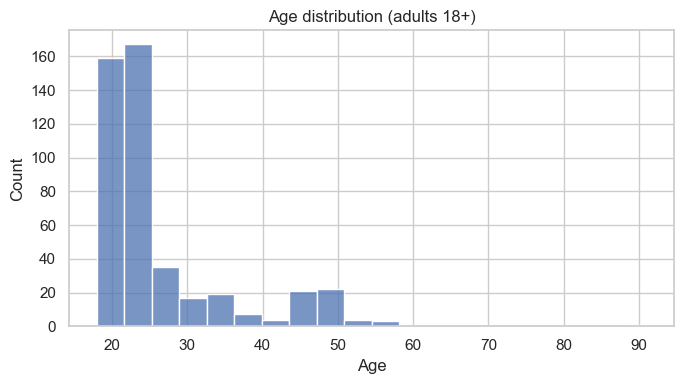

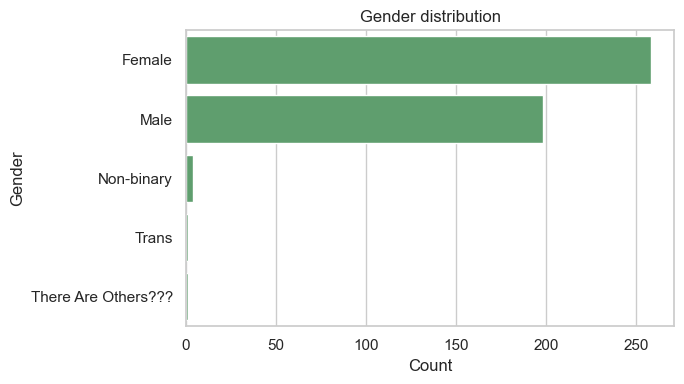

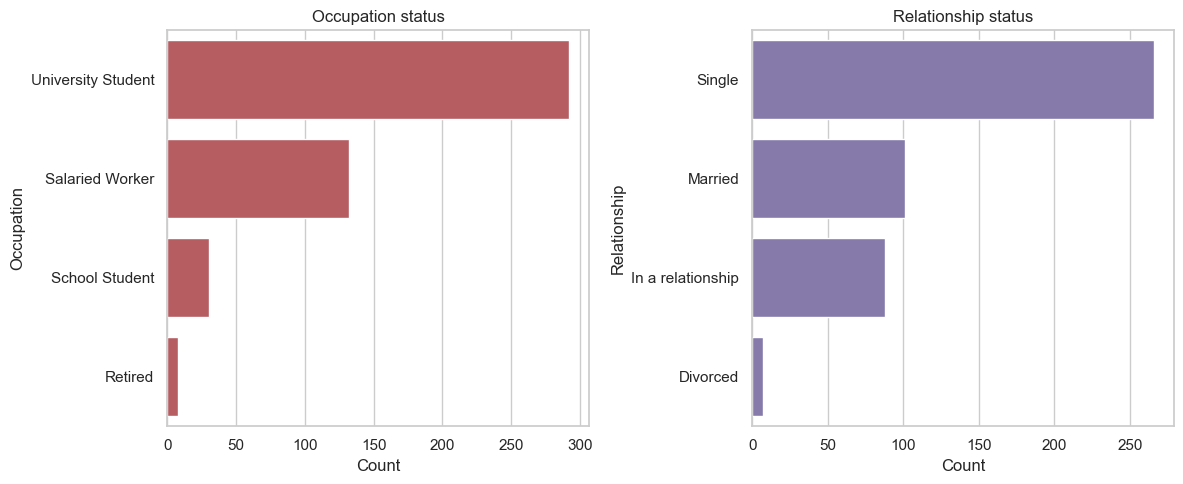

### Social media exposure in Dataset #4
The key exposure in this dataset is `avg_daily_time` (time spent per day, in categories). We also use `avg_daily_hours` as an approximate numeric proxy (midpoints of each category) for correlation/heatmap-style summaries.

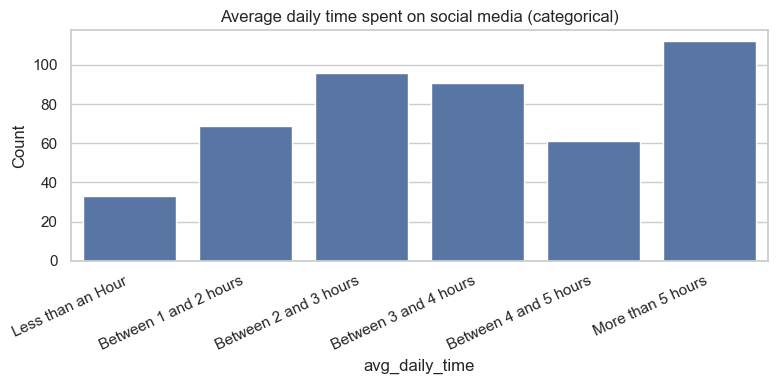

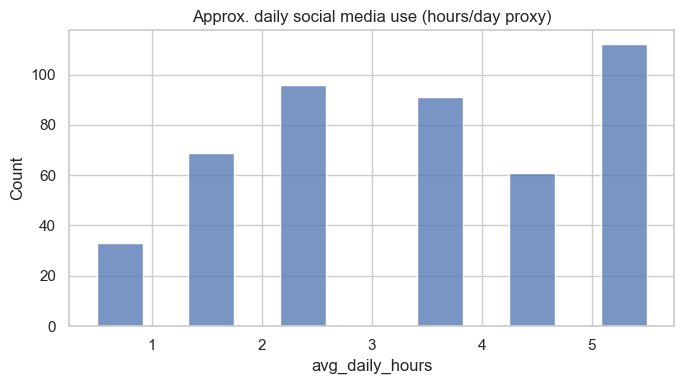

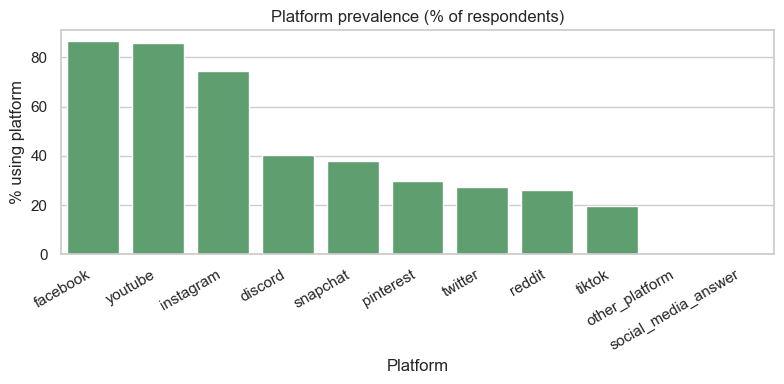

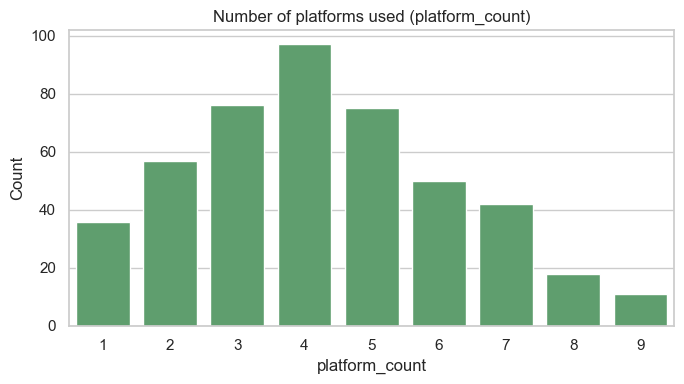

### Consistency check: uses_social_media
Some respondents answer `No` to using social media but still report time/platforms. We keep the original answer (`uses_social_media_original`) and define a cleaned `uses_social_media` that treats any reported usage fields as evidence of use.

,uses_social_media_original,uses_social_media
False,3,0
True,459,462


### Part 1 takeaways (Dataset #4)
Below are concrete summaries computed from the processed data (no hand-waving).

**Time spent distribution (%):**

,pct
avg_daily_time,
Less than an Hour,7.1
Between 1 and 2 hours,14.9
Between 2 and 3 hours,20.8
Between 3 and 4 hours,19.7
Between 4 and 5 hours,13.2
More than 5 hours,24.2


**Top platforms by prevalence (% using):**

,pct
facebook,86.6
youtube,85.9
instagram,74.2
discord,40.5
snapchat,38.1
pinterest,29.9
twitter,27.5
reddit,26.0


**Platform breadth:** median `platform_count` = **4** (IQR: **3**).

**How this maps to our research question:** Dataset #4 does not directly measure active interaction (posting/commenting/DMs). Here we treat `avg_daily_time` and related survey behaviors (e.g., comparison/validation, distracted use) as **supporting proxies** for passive-style exposure and pathways.

In [13]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")

# Always reload processed data for EDA (fast + reproducible)
df = pd.read_csv("data/02-processed/smmh_processed.csv")

# Coerce boolean-like columns that may reload as strings ("True"/"False")
def _coerce_bool(s: pd.Series) -> pd.Series:
    if str(s.dtype) in {"bool", "boolean"}:
        return s.astype("boolean")
    s2 = s.astype("string").str.strip().str.lower()
    return s2.map({"true": True, "false": False}).astype("boolean")

for bcol in ["uses_social_media_original", "uses_social_media"]:
    if bcol in df.columns:
        df[bcol] = _coerce_bool(df[bcol])

display(Markdown("""### Load processed Dataset #4\nWe explicitly load the processed table from `data/02-processed/` (as recommended in the template) to keep EDA reproducible without re-running all wrangling."""))
print("Loaded df shape:", df.shape)
display(df.head(3))

# Basic checks
print("Duplicate rows:", df.duplicated().sum())
print("Age min/max:", df["age"].min(), df["age"].max())

missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
      .sort_values("missing_count", ascending=False)
)
display(Markdown("""### Missingness overview\nWe check missing values so we know which variables can be used directly in later analyses and which may need careful handling."""))
display(missing.query("missing_count > 0").head(20))

# ---- Sample characteristics ----
display(Markdown("""### Who is in the sample?\nBecause our research question focuses on adults, we confirm the processed dataset is restricted to age 18+ and then summarize the demographic composition."""))

age_median = float(df["age"].median())
age_iqr = float(df["age"].quantile(0.75) - df["age"].quantile(0.25))
print(f"Median age: {age_median:.1f} (IQR: {age_iqr:.1f})")

plt.figure(figsize=(7, 4))
sns.histplot(df["age"].dropna(), bins=20, color="#4C72B0")
plt.title("Age distribution (adults 18+)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Gender distribution
plt.figure(figsize=(7, 4))
gender_order = df["gender"].value_counts(dropna=False).index
sns.countplot(data=df, y="gender", order=gender_order, color="#55A868")
plt.title("Gender distribution")
plt.xlabel("Count")
plt.ylabel("Gender")
plt.tight_layout()
plt.show()

# Occupation and relationship status (context for potential confounding)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)
occ_order = df["occupation_status"].value_counts(dropna=False).index
rel_order = df["relationship_status"].value_counts(dropna=False).index
sns.countplot(data=df, y="occupation_status", order=occ_order, ax=axes[0], color="#C44E52")
axes[0].set_title("Occupation status")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Occupation")

sns.countplot(data=df, y="relationship_status", order=rel_order, ax=axes[1], color="#8172B2")
axes[1].set_title("Relationship status")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Relationship")

plt.tight_layout()
plt.show()

# ---- Social media exposure variables ----
display(Markdown("""### Social media exposure in Dataset #4\nThe key exposure in this dataset is `avg_daily_time` (time spent per day, in categories). We also use `avg_daily_hours` as an approximate numeric proxy (midpoints of each category) for correlation/heatmap-style summaries."""))

# Ordered categories for consistent plotting
avg_time_order = [
    "Less than an Hour",
    "Between 1 and 2 hours",
    "Between 2 and 3 hours",
    "Between 3 and 4 hours",
    "Between 4 and 5 hours",
    "More than 5 hours",
]

# Distribution of time-spent categories
plt.figure(figsize=(8, 4))
time_counts = (
    df["avg_daily_time"]
      .astype("string")
      .value_counts(dropna=False)
      .reindex(avg_time_order)
)
# Some categories may be absent; drop NaNs in index order
plot_counts = time_counts.dropna()
sns.barplot(x=plot_counts.index, y=plot_counts.values, color="#4C72B0")
plt.title("Average daily time spent on social media (categorical)")
plt.xlabel("avg_daily_time")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Numeric proxy distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["avg_daily_hours"].dropna().astype(float), bins=12, color="#4C72B0")
plt.title("Approx. daily social media use (hours/day proxy)")
plt.xlabel("avg_daily_hours")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Platform prevalence
platform_cols = [
    c for c in df.columns
    if c.startswith("uses_") and c not in {"uses_social_media", "uses_social_media_original"}
]
platform_bool = df[platform_cols].apply(_coerce_bool)
platform_rates = platform_bool.mean().sort_values(ascending=False).mul(100)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=platform_rates.index.str.replace("uses_", "", regex=False),
    y=platform_rates.values,
    color="#55A868",
)
plt.title("Platform prevalence (% of respondents)")
plt.xlabel("Platform")
plt.ylabel("% using platform")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Platform count distribution
plt.figure(figsize=(7, 4))
sns.countplot(x="platform_count", data=df, color="#55A868")
plt.title("Number of platforms used (platform_count)")
plt.xlabel("platform_count")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Brief check of the (cleaned vs original) social media use indicator
use_table = {}
for col in ["uses_social_media_original", "uses_social_media"]:
    use_table[col] = df[col].astype("string").value_counts(dropna=False)
use_table = pd.DataFrame(use_table).fillna(0).astype(int)
display(Markdown("""### Consistency check: uses_social_media\nSome respondents answer `No` to using social media but still report time/platforms. We keep the original answer (`uses_social_media_original`) and define a cleaned `uses_social_media` that treats any reported usage fields as evidence of use."""))
display(use_table)

# ---- Quick, data-backed takeaways for Part 1 (so the figures are interpreted) ----
display(Markdown("""### Part 1 takeaways (Dataset #4)\nBelow are concrete summaries computed from the processed data (no hand-waving)."""))

# Time-spent distribution (percent)
time_dist_pct = (
    df["avg_daily_time"].astype("string").value_counts(normalize=True).mul(100).reindex(avg_time_order)
)
time_dist_pct = time_dist_pct.fillna(0).round(1).to_frame("pct")
display(Markdown("**Time spent distribution (%):**"))
display(time_dist_pct)

# Top platforms
platform_rates_clean = platform_rates.copy().rename(lambda s: s.replace("uses_", ""))
display(Markdown("**Top platforms by prevalence (% using):**"))
display(platform_rates_clean.head(8).round(1).to_frame("pct"))

# Platform count summary
pc_med = float(df["platform_count"].median())
pc_iqr = float(df["platform_count"].quantile(0.75) - df["platform_count"].quantile(0.25))
display(Markdown(f"**Platform breadth:** median `platform_count` = **{pc_med:.0f}** (IQR: **{pc_iqr:.0f}**)."))

# Note about scope vs research question
rq_note = (
    "**How this maps to our research question:** Dataset #4 does not directly measure active interaction (posting/commenting/DMs). "
    "Here we treat `avg_daily_time` and related survey behaviors (e.g., comparison/validation, distracted use) as **supporting proxies** for passive-style exposure and pathways."
)
display(Markdown(rq_note))

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

#### Dataset #4 EDA (Part 2): Mental health proxy distributions + relationships

In this section, we explore distributions of key mental-health/wellbeing proxy variables (Likert 1–5), and then examine how they vary with:
- **time spent on social media** (`avg_daily_time` / `avg_daily_hours`)
- **passive-style behaviors** like using social media without a purpose and getting distracted
- **social comparison / validation** behaviors

Because this is observational survey data, we interpret patterns as **associations** only (not causal effects).

All rows: 462 | Social media users (cleaned): 462


### Distributions of key wellbeing / mental-health proxy variables
These survey items are on a **1–5 scale** (ordinal), so we focus on distributions (counts) and medians rather than only means.

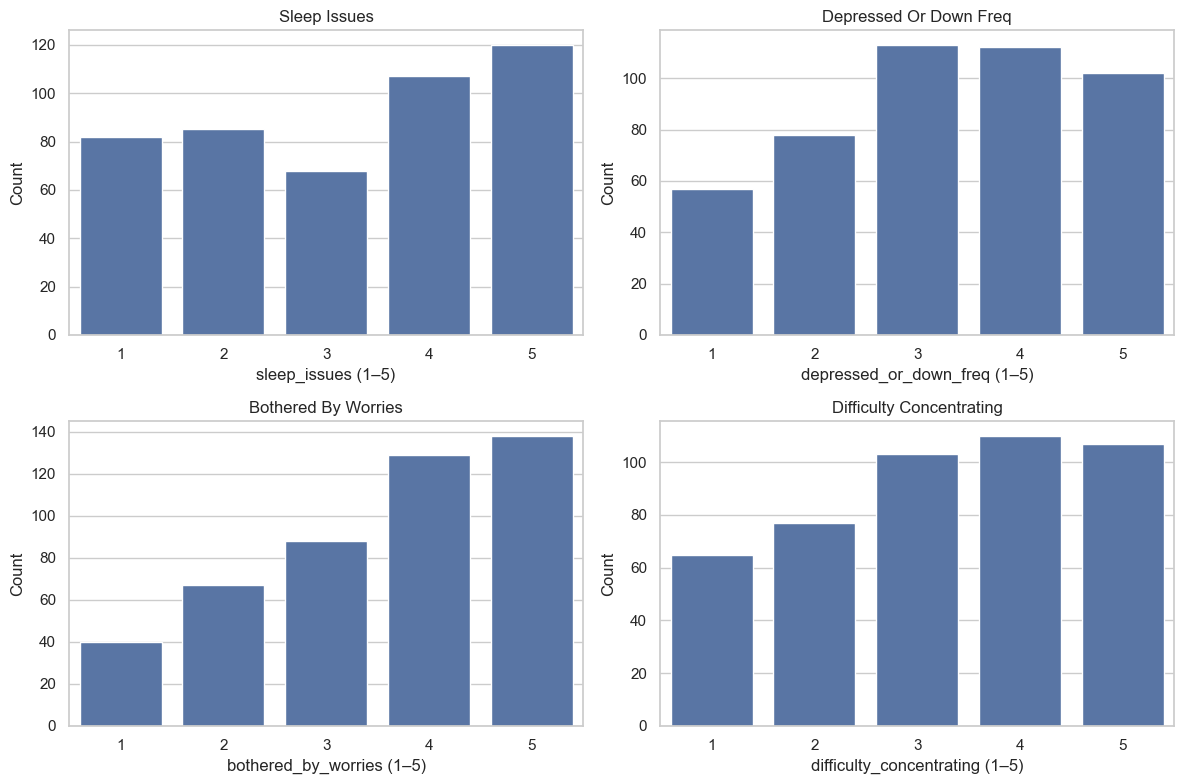

Median sleep_issues: 3.0
Median depressed_or_down_freq: 3.0
Median bothered_by_worries: 4.0
Median difficulty_concentrating: 3.0


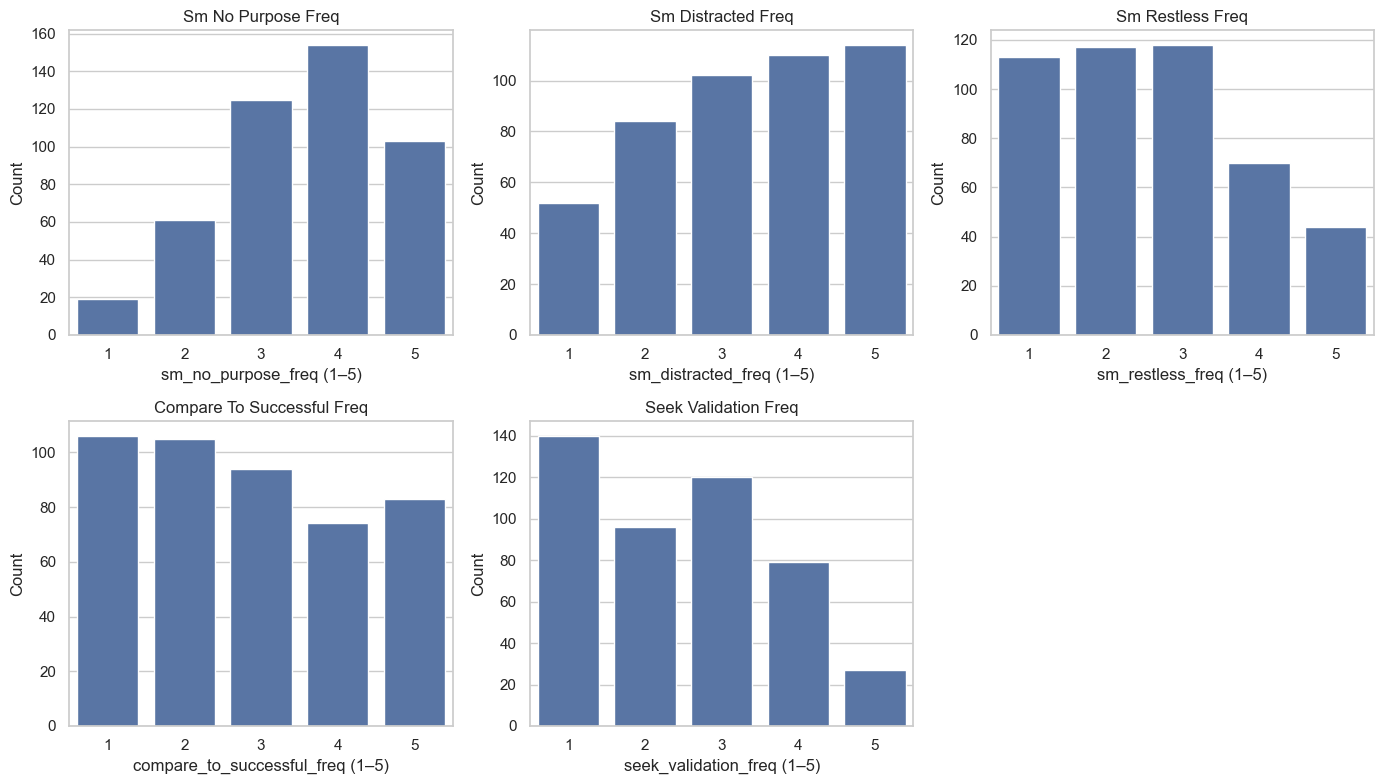

### Feelings about comparisons
This categorical item gives context for how respondents interpret their social comparison experiences.

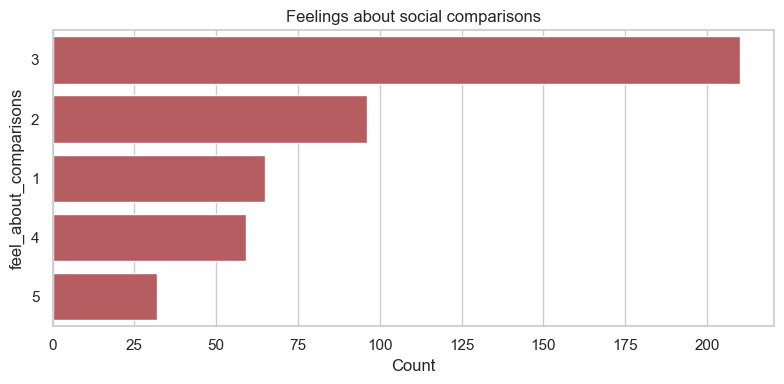

### Association between time spent and outcomes
We compare distributions of outcomes across `avg_daily_time` categories. These are ordinal outcomes, so boxplots + jittered points help show distributional shifts without implying a linear relationship.

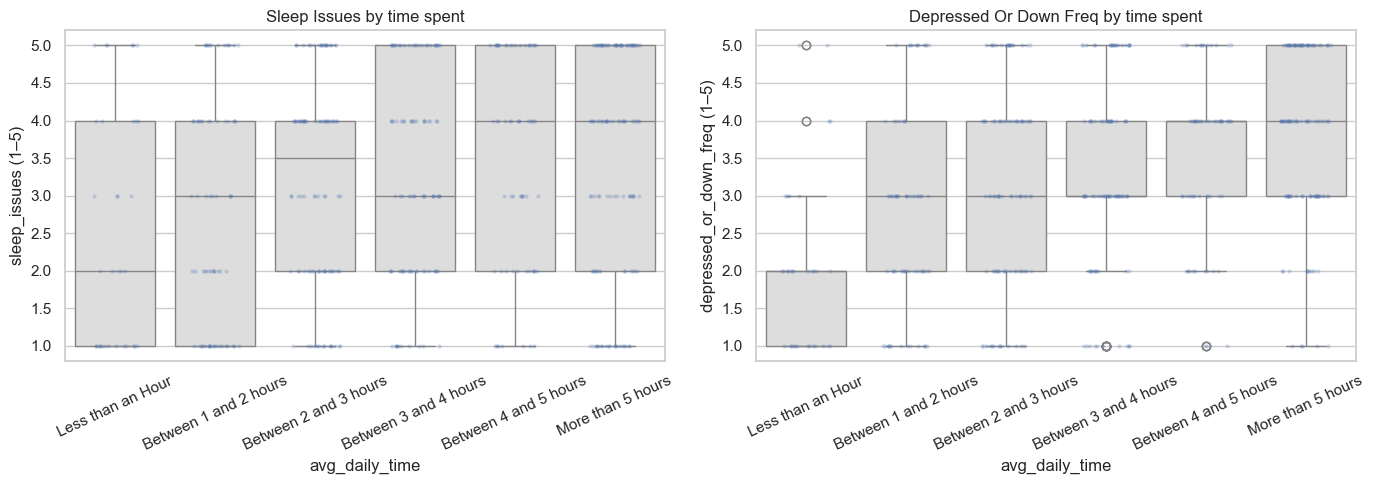

**Median outcomes by time-spent category (users only):**

,sleep_issues,depressed_or_down_freq
avg_daily_time,,
Less than an Hour,2.0,2.0
Between 1 and 2 hours,3.0,3.0
Between 2 and 3 hours,3.5,3.0
Between 3 and 4 hours,3.0,3.0
Between 4 and 5 hours,4.0,4.0
More than 5 hours,4.0,4.0


**Spearman correlation with time proxy (`avg_daily_hours`):**

,spearman_r
sleep_issues,0.170
depressed_or_down_freq,0.333


### Comparison / validation behaviors vs outcomes
These behaviors are plausible pathways connecting social media use to wellbeing outcomes (e.g., more comparison or validation-seeking may co-occur with worse mood/sleep).

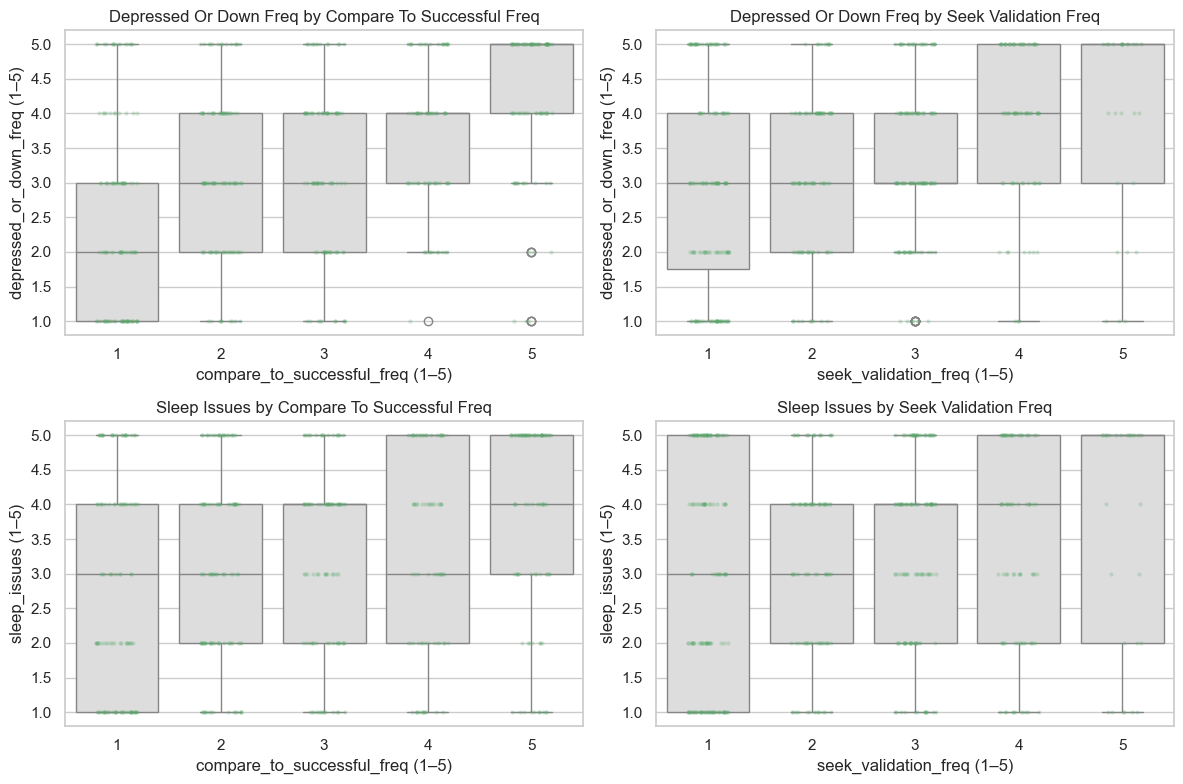

### Correlation structure (Spearman)
For ordinal variables, Spearman correlation is a more appropriate summary than Pearson. This helps identify clusters (e.g., distraction/restlessness/comparison/validation) and how they relate to outcomes.

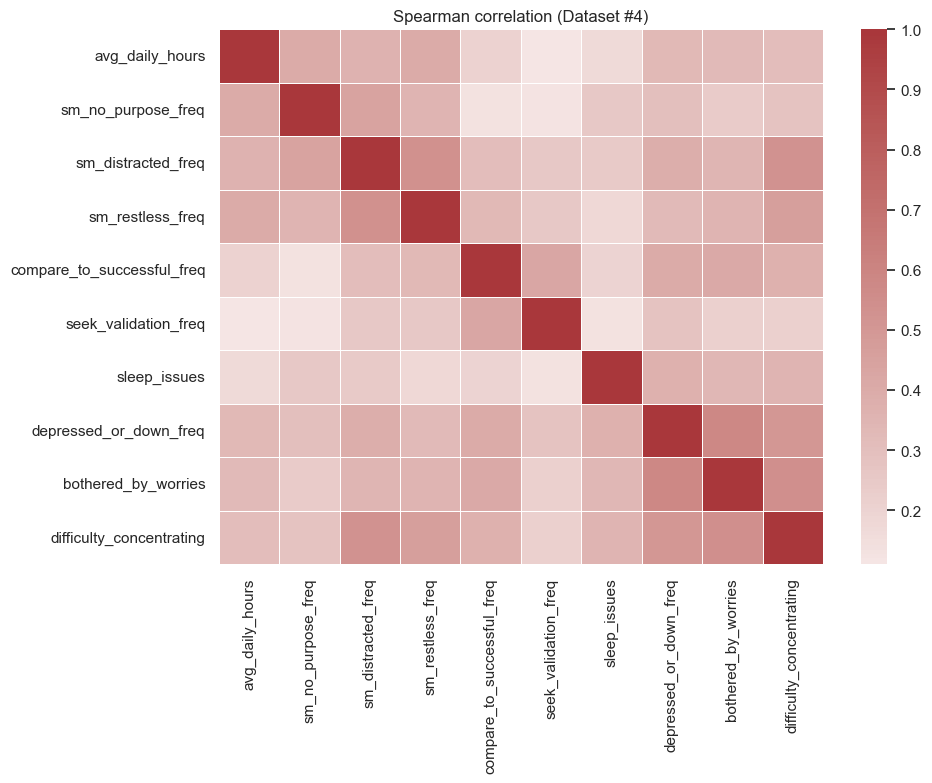

### EDA takeaways (Dataset #4)
These are **associations** in a cross-sectional survey (no causal claims).

**1) Time spent vs outcomes:** Median outcome levels by `avg_daily_time` are shown above; this tells us whether higher-use categories tend to report more sleep issues / depressed-down frequency in this sample.

**Top correlates with `sleep_issues` (Spearman):**

,spearman_r
depressed_or_down_freq,0.369
difficulty_concentrating,0.359
bothered_by_worries,0.342
sm_no_purpose_freq,0.257
sm_distracted_freq,0.248
compare_to_successful_freq,0.202


**Top correlates with `depressed_or_down_freq` (Spearman):**

,spearman_r
bothered_by_worries,0.583
difficulty_concentrating,0.505
compare_to_successful_freq,0.404
sm_distracted_freq,0.387
sleep_issues,0.369
avg_daily_hours,0.333


**How this informs next steps:** Based on the strongest associations, we would prioritize modeling outcomes like `sleep_issues` and `depressed_or_down_freq` as functions of time-spent and comparison/validation variables, while treating predictors/outcomes as ordinal/categorical where appropriate and controlling for demographics (age, gender, occupation, relationship status) to reduce confounding.

In [14]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")

# Focus EDA on respondents with evidence of social media use
# (otherwise time spent/platform variables can be missing/irrelevant)
df_use = df[df["uses_social_media"].fillna(False) == True].copy()

print("All rows:", len(df), "| Social media users (cleaned):", len(df_use))

# Helper: Likert distribution plot (ordinal-aware)
def likert_distribution(data, col, title=None, ax=None):
    if ax is None:
        ax = plt.gca()
    vc = data[col].value_counts(dropna=False).sort_index()
    # Ensure 1–5 are shown (even if some levels missing)
    for k in [1, 2, 3, 4, 5]:
        if k not in vc.index:
            vc.loc[k] = 0
    vc = vc.sort_index()
    sns.barplot(x=vc.index.astype(str), y=vc.values, ax=ax, color="#4C72B0")
    ax.set_title(title or col)
    ax.set_xlabel(f"{col} (1–5)")
    ax.set_ylabel("Count")
    return ax

# ---- Distributions of key outcomes/proxies ----
display(Markdown("""### Distributions of key wellbeing / mental-health proxy variables\nThese survey items are on a **1–5 scale** (ordinal), so we focus on distributions (counts) and medians rather than only means."""))

key_outcomes = [
    "sleep_issues",
    "depressed_or_down_freq",
    "bothered_by_worries",
    "difficulty_concentrating",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, key_outcomes):
    likert_distribution(df_use, col, title=col.replace("_", " ").title(), ax=ax)
plt.tight_layout()
plt.show()

for col in key_outcomes:
    med = df_use[col].median(skipna=True)
    print(f"Median {col}: {med}")

# Additional behavior proxies relevant to the research question pathways
behavior_cols = [
    "sm_no_purpose_freq",
    "sm_distracted_freq",
    "sm_restless_freq",
    "compare_to_successful_freq",
    "seek_validation_freq",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, col in enumerate(behavior_cols):
    likert_distribution(df_use, col, title=col.replace("_", " ").title(), ax=axes[i])
# Remove any unused subplot axis
for j in range(len(behavior_cols), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

# Distribution of feelings about comparisons (categorical)
display(Markdown("""### Feelings about comparisons\nThis categorical item gives context for how respondents interpret their social comparison experiences."""))
plt.figure(figsize=(8, 4))
order = df_use["feel_about_comparisons"].value_counts(dropna=False).index
sns.countplot(data=df_use, y="feel_about_comparisons", order=order, color="#C44E52")
plt.title("Feelings about social comparisons")
plt.xlabel("Count")
plt.ylabel("feel_about_comparisons")
plt.tight_layout()
plt.show()

# ---- Relationships: time spent vs outcomes ----
display(Markdown("""### Association between time spent and outcomes\nWe compare distributions of outcomes across `avg_daily_time` categories. These are ordinal outcomes, so boxplots + jittered points help show distributional shifts without implying a linear relationship."""))

avg_time_order = [
    "Less than an Hour",
    "Between 1 and 2 hours",
    "Between 2 and 3 hours",
    "Between 3 and 4 hours",
    "Between 4 and 5 hours",
    "More than 5 hours",
]

df_use_plot = df_use.dropna(subset=["avg_daily_time"]).copy()
df_use_plot["avg_daily_time"] = pd.Categorical(df_use_plot["avg_daily_time"], categories=avg_time_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, outcome in zip(axes, ["sleep_issues", "depressed_or_down_freq"]):
    sns.boxplot(data=df_use_plot, x="avg_daily_time", y=outcome, ax=ax, color="#DDDDDD")
    sns.stripplot(
        data=df_use_plot,
        x="avg_daily_time",
        y=outcome,
        ax=ax,
        color="#4C72B0",
        alpha=0.25,
        jitter=0.25,
        size=3,
    )
    ax.set_title(f"{outcome.replace('_', ' ').title()} by time spent")
    ax.set_xlabel("avg_daily_time")
    ax.set_ylabel(f"{outcome} (1–5)")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# Numeric summaries to interpret the time-spent plots
med_by_time = (
    df_use_plot.groupby("avg_daily_time", observed=True)[["sleep_issues", "depressed_or_down_freq"]]
      .median()
      .round(2)
)
display(Markdown("**Median outcomes by time-spent category (users only):**"))
display(med_by_time)

# Spearman correlation between numeric time proxy and outcomes (users only)
spearman_time = (
    df_use[["avg_daily_hours", "sleep_issues", "depressed_or_down_freq"]]
      .astype(float)
      .corr(method="spearman")
      .loc["avg_daily_hours", ["sleep_issues", "depressed_or_down_freq"]]
      .round(3)
)
display(Markdown("**Spearman correlation with time proxy (`avg_daily_hours`):**"))
display(spearman_time.to_frame("spearman_r"))

# ---- Relationships: comparison/validation vs outcomes ----
display(Markdown("""### Comparison / validation behaviors vs outcomes\nThese behaviors are plausible pathways connecting social media use to wellbeing outcomes (e.g., more comparison or validation-seeking may co-occur with worse mood/sleep)."""))

pairs = [
    ("compare_to_successful_freq", "depressed_or_down_freq"),
    ("seek_validation_freq", "depressed_or_down_freq"),
    ("compare_to_successful_freq", "sleep_issues"),
    ("seek_validation_freq", "sleep_issues"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.ravel()
for ax, (x, y) in zip(axes, pairs):
    tmp = df_use.dropna(subset=[x, y]).copy()
    # x is Likert 1–5; show outcome distribution by x level
    sns.boxplot(data=tmp, x=x, y=y, ax=ax, color="#DDDDDD")
    sns.stripplot(data=tmp, x=x, y=y, ax=ax, color="#55A868", alpha=0.25, jitter=0.2, size=3)
    ax.set_title(f"{y.replace('_', ' ').title()} by {x.replace('_', ' ').title()}")
    ax.set_xlabel(f"{x} (1–5)")
    ax.set_ylabel(f"{y} (1–5)")
plt.tight_layout()
plt.show()

# ---- Spearman correlation heatmap (ordinal-friendly) ----
display(Markdown("""### Correlation structure (Spearman)\nFor ordinal variables, Spearman correlation is a more appropriate summary than Pearson. This helps identify clusters (e.g., distraction/restlessness/comparison/validation) and how they relate to outcomes."""))

corr_cols = [
    "avg_daily_hours",
    "sm_no_purpose_freq",
    "sm_distracted_freq",
    "sm_restless_freq",
    "compare_to_successful_freq",
    "seek_validation_freq",
    "sleep_issues",
    "depressed_or_down_freq",
    "bothered_by_worries",
    "difficulty_concentrating",
]

corr_df = df_use[corr_cols].copy()
# Cast to float for correlation (keeps NaNs)
corr = corr_df.astype(float).corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.5)
plt.title("Spearman correlation (Dataset #4)")
plt.tight_layout()
plt.show()

# ---- EDA wrap-up ----
# Pull out a small number of concrete, data-backed takeaways

# Strongest correlates with each outcome (absolute Spearman)
def top_abs_corr(corr_mat: pd.DataFrame, target: str, k: int = 5) -> pd.DataFrame:
    s = corr_mat[target].drop(index=target).dropna()
    out = (
        s.reindex(s.abs().sort_values(ascending=False).index)
         .head(k)
         .to_frame("spearman_r")
         .round(3)
    )
    return out

display(Markdown("""### EDA takeaways (Dataset #4)\nThese are **associations** in a cross-sectional survey (no causal claims)."""))

# Takeaway 1: time-spent pattern (medians)
if not med_by_time.empty:
    lo = med_by_time.index.min()
    hi = med_by_time.index.max()
    display(Markdown("**1) Time spent vs outcomes:** Median outcome levels by `avg_daily_time` are shown above; this tells us whether higher-use categories tend to report more sleep issues / depressed-down frequency in this sample."))

# Takeaway 2: comparison/validation correlates
corr_targets = ["sleep_issues", "depressed_or_down_freq"]
for t in corr_targets:
    display(Markdown(f"**Top correlates with `{t}` (Spearman):**"))
    display(top_abs_corr(corr, t, k=6))

# Takeaway 3: what to model next
next_steps = (
    "**How this informs next steps:** Based on the strongest associations, we would prioritize modeling outcomes like `sleep_issues` and `depressed_or_down_freq` as functions of time-spent and comparison/validation variables, "
    "while treating predictors/outcomes as ordinal/categorical where appropriate and controlling for demographics (age, gender, occupation, relationship status) to reduce confounding."
)
display(Markdown(next_steps))

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them